In [ ]:
import os, zipfile, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Try to import TensorFlow / Keras
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    raise ImportError("TensorFlow is required to run the training. "
                      "If you are in Colab, TF is preinstalled. "
                      "Locally run: pip install tensorflow") from e

In [ ]:
# ---------------------------
# Use the correct path to the zip file
zip_path = "/content/student+performance.zip"
if not os.path.exists(zip_path):
    # Try current directory if running locally
    zip_path = "student+performance.zip"

assert os.path.exists(zip_path), f"Zip file not found at {zip_path}. Upload or set path."

extract_dir = "/mnt/data/student_performance_unzipped"
os.makedirs(extract_dir, exist_ok=True)

# Extract the outer zip file
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# Now extract the inner zip file (assuming student.zip is inside)
inner_zip_path = os.path.join(extract_dir, "student.zip")
if os.path.exists(inner_zip_path):
    with zipfile.ZipFile(inner_zip_path, 'r') as z_inner:
        z_inner.extractall(extract_dir)
    print(f"Extracted contents of {inner_zip_path}")
else:
    print(f"Inner zip file {inner_zip_path} not found. Listing contents of {extract_dir}:")

# List the contents of the extraction directory to verify
print("Contents of extraction directory:")
!ls -l {extract_dir}

Extracted contents of /mnt/data/student_performance_unzipped/student.zip
Contents of extraction directory:
total 176
-rw-r--r-- 1 root root 56993 Oct 18 09:17 student-mat.csv
-rw-r--r-- 1 root root   269 Oct 18 09:17 student-merge.R
-rw-r--r-- 1 root root 93220 Oct 18 09:17 student-por.csv
-rw-r--r-- 1 root root  3206 Oct 18 09:17 student.txt
-rw-r--r-- 1 root root 20478 Oct 18 09:17 student.zip


In [ ]:
csv_files = [f for f in os.listdir(extract_dir) if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)
# pick student-mat.csv if exists else first
csv_choice = None
for f in csv_files:
    if "mat" in f.lower():
        csv_choice = f
        break

# Handle the case where no CSV files are found
if csv_choice is None:
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {extract_dir}")
    csv_choice = csv_files[0]

csv_path = os.path.join(extract_dir, csv_choice)
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path, sep=';')
print("Data shape:", df.shape)
display(df.head())

CSV files found: ['student-mat.csv', 'student-por.csv']
Using CSV: /mnt/data/student_performance_unzipped/student-mat.csv
Data shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
!ls -l /mnt/data/student_performance_unzipped

total 20
-rw-r--r-- 1 root root 20478 Oct 18 09:16 student.zip


In [ ]:

# ---------------------------
# 2) Basic EDA & cleaning
# ---------------------------
print(df.info())
display(df.describe().T)

# Missing values
miss = df.isnull().sum()
print("Missing per column (non-zero shown):")
print(miss[miss>0])

# Duplicates
print("Duplicate rows count:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Outlier check using IQR for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = outlier_count
print("Outlier counts (IQR):")
print(outlier_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


Missing per column (non-zero shown):
Series([], dtype: int64)
Duplicate rows count: 0
Outlier counts (IQR):
{'age': np.int64(1), 'Medu': np.int64(0), 'Fedu': np.int64(2), 'traveltime': np.int64(8), 'studytime': np.int64(27), 'failures': np.int64(83), 'famrel': np.int64(26), 'freetime': np.int64(19), 'goout': np.int64(0), 'Dalc': np.int64(18), 'Walc': np.int64(0), 'health': np.int64(0), 'absences': np.int64(15), 'G1': np.int64(0), 'G2': np.int64(13), 'G3': np.int64(0)}


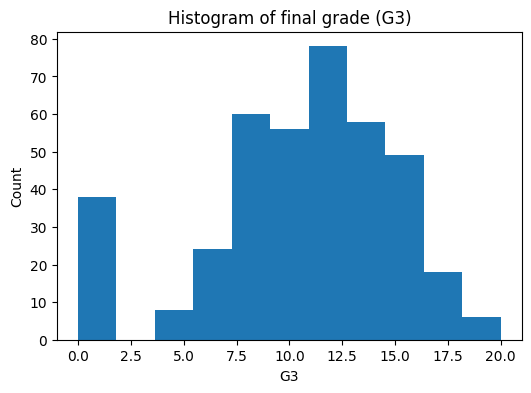

In [ ]:
# Histogram of target G3
plt.figure(figsize=(6,4))
plt.hist(df['G3'], bins=11)
plt.title("Histogram of final grade (G3)")
plt.xlabel("G3")
plt.ylabel("Count")
plt.show()

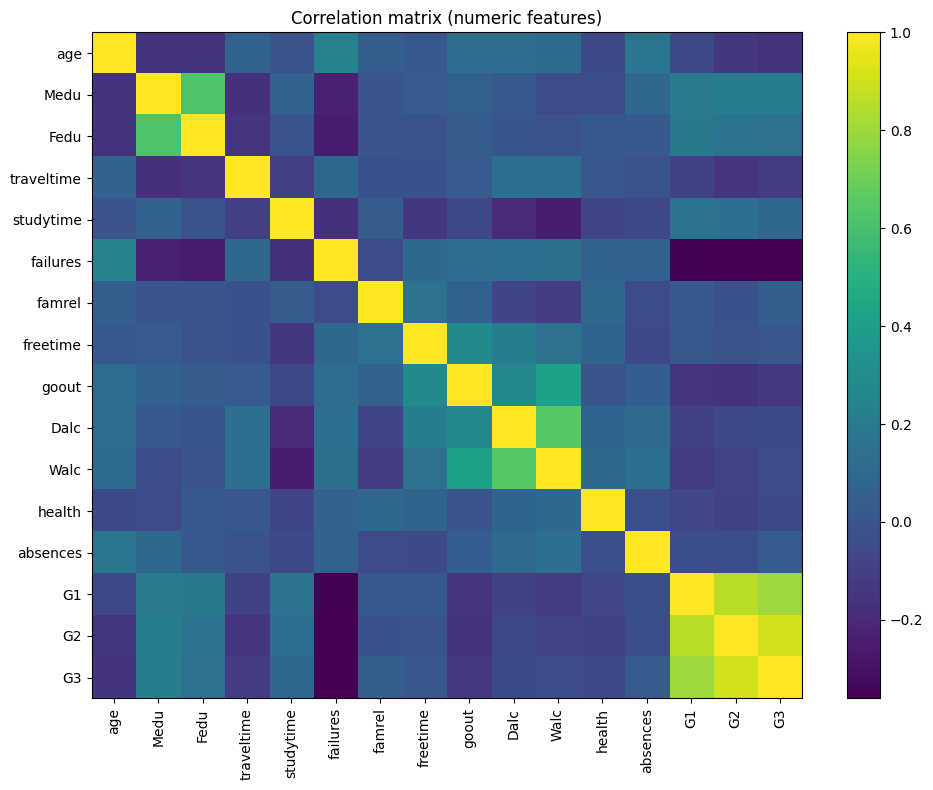

In [ ]:
# Correlation heatmap for numeric features
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1477207746.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_sex, labels=sex_unique)


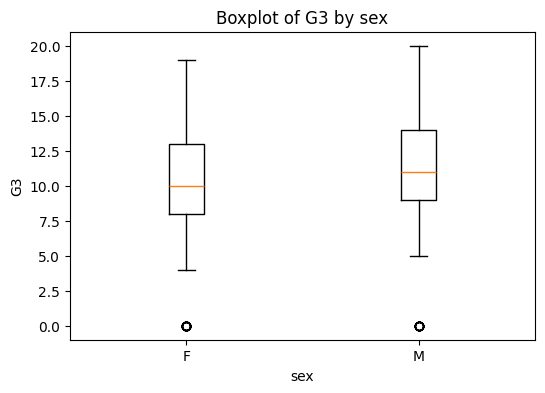

In [ ]:
# Boxplot of G3 by sex
plt.figure(figsize=(6,4))
sex_unique = list(df['sex'].unique())
data_by_sex = [df[df['sex']==s]['G3'] for s in sex_unique]
plt.boxplot(data_by_sex, labels=sex_unique)
plt.title("Boxplot of G3 by sex")
plt.xlabel("sex")
plt.ylabel("G3")
plt.show()

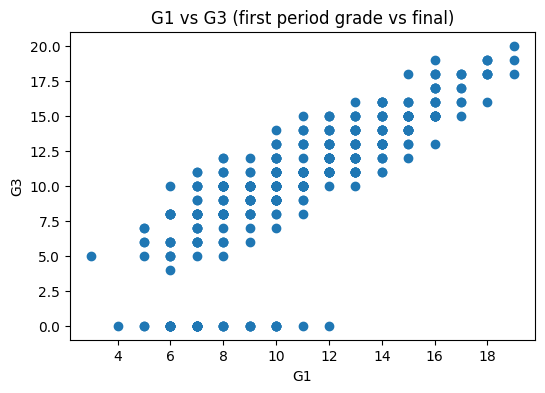

In [ ]:
# Scatter: G1 vs G3
plt.figure(figsize=(6,4))
plt.scatter(df['G1'], df['G3'])
plt.title("G1 vs G3 (first period grade vs final)")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()

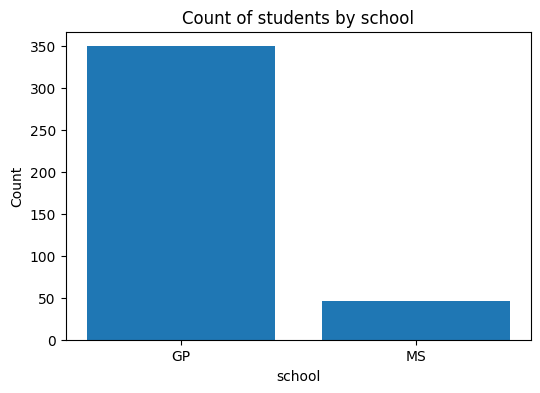

In [ ]:
# Bar chart: school counts
plt.figure(figsize=(6,4))
school_counts = df['school'].value_counts()
plt.bar(school_counts.index, school_counts.values)
plt.title("Count of students by school")
plt.xlabel("school")
plt.ylabel("Count")
plt.show()


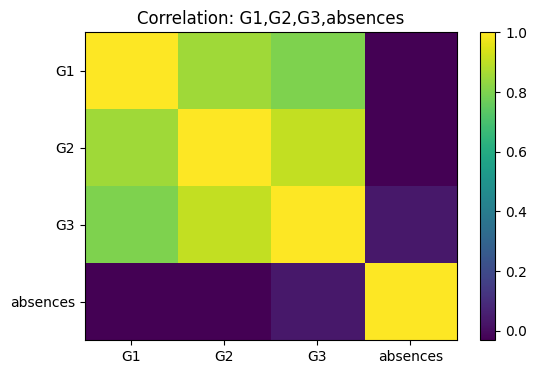

In [ ]:
subset = ['G1','G2','G3','absences']
plt.figure(figsize=(6,4))
plt.imshow(df[subset].corr(), interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(subset)), subset)
plt.yticks(range(len(subset)), subset)
plt.title("Correlation: G1,G2,G3,absences")
plt.show()

In [ ]:
target = 'G3'
X = df.drop(columns=[target])
y = df[target].astype(float).values

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)
print("Processed shape:", X_processed.shape)

Processed shape: (395, 58)


In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_processed, y, test_size=0.15, random_state=42)
# validation = 0.15 of total -> val size w.r.t train_full = 0.15/0.85 ≈ 0.17647
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.17647, random_state=42)

print("Shapes -> train, val, test:", X_train.shape, X_val.shape, X_test.shape)

# ---------------------------
# 6) Build MLP model factory
# ---------------------------
def build_mlp(input_dim, units=64, dropout_rate=0.0, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units, activation='relu'),
        layers.Dense(max(units//2, 16), activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=['mae'])
    return model

input_dim = X_train.shape[1]

# Simple hyperparameter sweep (small grid)
search_space = [
    {'units':64, 'lr':1e-3},
    {'units':128, 'lr':1e-3},
    {'units':64, 'lr':1e-4},
]

best_val_rmse = float('inf')
best_model = None
best_hist = None
best_params = None

for params in search_space:
    print("Training with:", params)
    model = build_mlp(input_dim, units=params['units'], lr=params['lr'], dropout_rate=0.1)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=80, batch_size=32, verbose=1)
    val_preds = model.predict(X_val).flatten()
    val_rmse = math.sqrt(mean_squared_error(y_val, val_preds))
    print("Val RMSE:", val_rmse)
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model = model
        best_hist = history
        best_params = params

print("Best params:", best_params, "Val RMSE:", best_val_rmse)


Shapes -> train, val, test: (275, 58) (60, 58) (60, 58)
Training with: {'units': 64, 'lr': 0.001}
Epoch 1/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 127.6230 - mae: 10.4969 - val_loss: 111.7958 - val_mae: 9.3115
Epoch 2/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 115.7765 - mae: 9.8964 - val_loss: 96.1449 - val_mae: 8.7017
Epoch 3/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 95.8002 - mae: 9.0278 - val_loss: 77.8073 - val_mae: 7.8871
Epoch 4/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 77.5561 - mae: 8.1401 - val_loss: 55.7702 - val_mae: 6.7304
Epoch 5/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 48.3605 - mae: 6.2752 - val_loss: 34.1528 - val_mae: 5.1999
Epoch 6/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25.6945 - mae: 4.2888 - val_loss: 22.7918 - val_mae: 3.7742
Epoch 7/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.4851 - mae: 2.7986 - val_loss: 22.1303 - val_mae: 3.3742
Epoch 8/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.0553 - mae: 2.7067 - 

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Val RMSE: 3.4238670105522964
Best params: {'units': 128, 'lr': 0.001} Val RMSE: 2.3941497840392745


In [ ]:
# ---------------------------
# 7) Evaluate on test
# ---------------------------
test_preds = best_model.predict(X_test).flatten()
test_rmse = math.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)
print(f"Test RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}, Test R2: {test_r2:.4f}")

# Save model and preprocess pipeline
model_path = "student_mlp_regressor.h5"
best_model.save(model_path)
pipeline_path = "preprocessing_pipeline.joblib"
joblib.dump(preprocessor, pipeline_path)
print("Saved model to:", model_path)
print("Saved preprocessing pipeline to:", pipeline_path)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Test RMSE: 2.5118, Test MAE: 1.7119, Test R2: 0.7147
Saved model to: student_mlp_regressor.h5
Saved preprocessing pipeline to: preprocessing_pipeline.joblib


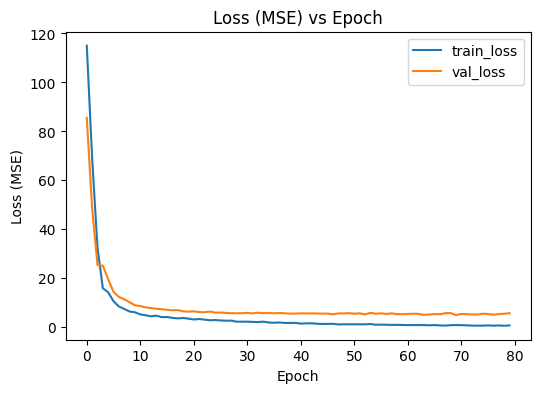

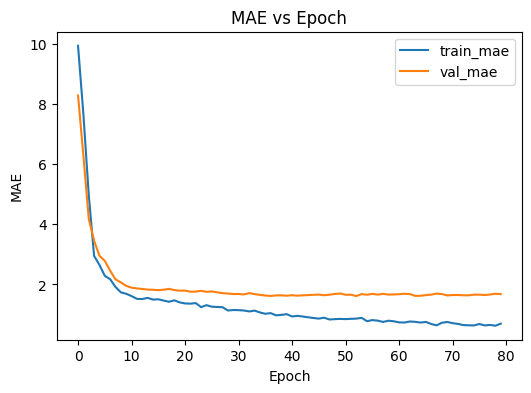

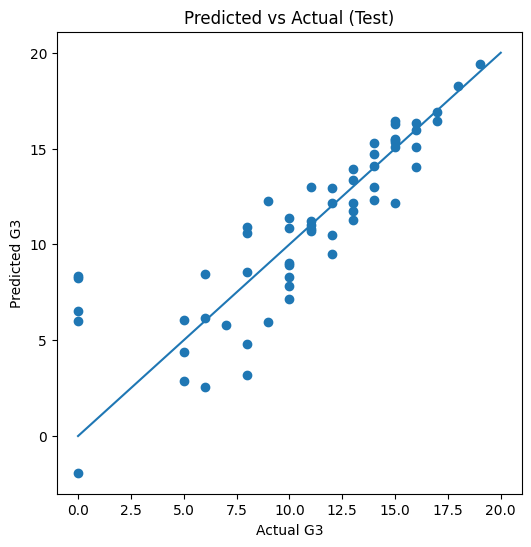

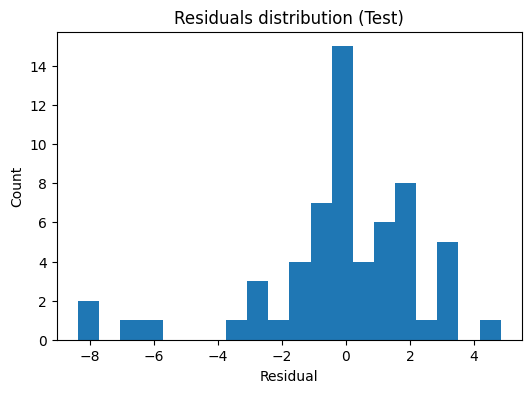

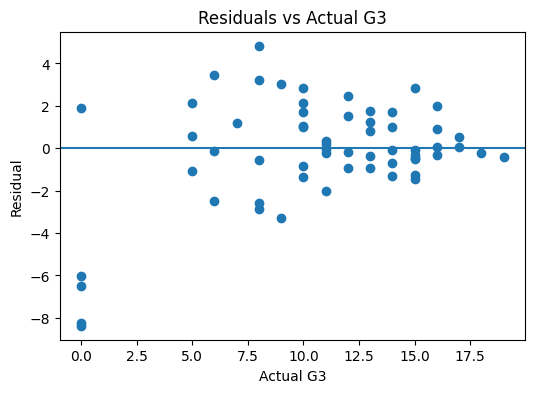

,metric,value
0,Test RMSE,2.511818
1,Test MAE,1.711863
2,Test R2,0.714672


In [ ]:
# 8) Plots: training curves, predicted vs actual, residuals
# ---------------------------
hist = best_hist.history

plt.figure(figsize=(6,4))
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.title("Loss (MSE) vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist['mae'], label='train_mae')
plt.plot(hist['val_mae'], label='val_mae')
plt.title("MAE vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_preds)
plt.plot([0,20],[0,20])
plt.title("Predicted vs Actual (Test)")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.show()

residuals = y_test - test_preds
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residuals distribution (Test)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_test, residuals)
plt.axhline(0)
plt.title("Residuals vs Actual G3")
plt.xlabel("Actual G3")
plt.ylabel("Residual")
plt.show()

# Summarize metrics in table form for the report
metrics_df = pd.DataFrame({
    "metric": ["Test RMSE", "Test MAE", "Test R2"],
    "value": [test_rmse, test_mae, test_r2]
})
display(metrics_df)